# Martini Pioniers Training


# AI Workshop – Katten vs Honden classificatie

In deze workshop gaan we een simpel AI-model trainen dat afbeeldingen kan herkennen.

Het doel van het model:
- kijken naar een afbeelding
- voorspellen of het een **kat** of **hond** is

Dit is een voorbeeld van **classification** binnen machine learning.

Classification betekent:
> een model dat een **categorie** voorspelt.

In [12]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [15]:
(dataset_train, dataset_test), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:15%]", "train[15%:20%]"],
    as_supervised=True,
    with_info=True
)
print(info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [16]:
IMG_SIZE = 160
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_ds = dataset_train.map(preprocess).batch(BATCH_SIZE)
test_ds = dataset_test.map(preprocess).batch(BATCH_SIZE)

## Bekijk de afbeeldingen

Hieronder zien we een aantal voorbeelden uit de dataset.

Kun jij al zien welke katten zijn en welke honden?

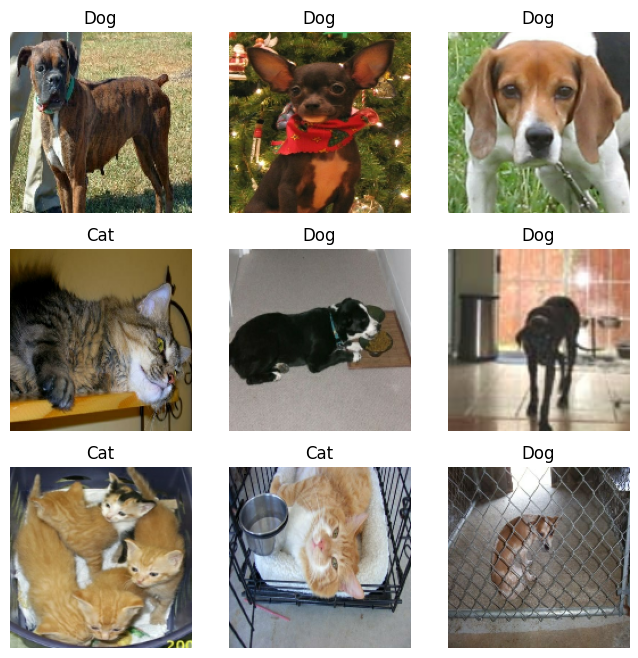

In [18]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title("Dog" if labels[i] else "Cat")
        plt.axis("off")

plt.show()

## Model maken

We maken een klein neuraal netwerk dat leert patronen in afbeeldingen te herkennen.

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation="relu",input_shape=(160,160,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model trainen

Nu gaat het model leren van duizenden afbeeldingen.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
 48/110 ━━━━━━━━━━━━━━━━━━━━ 1:18 1s/step - accuracy: 0.5284 - loss: 0.8496

## Wat voorspelt het model?

Hieronder zie je nieuwe afbeeldingen en wat het model denkt dat het is.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


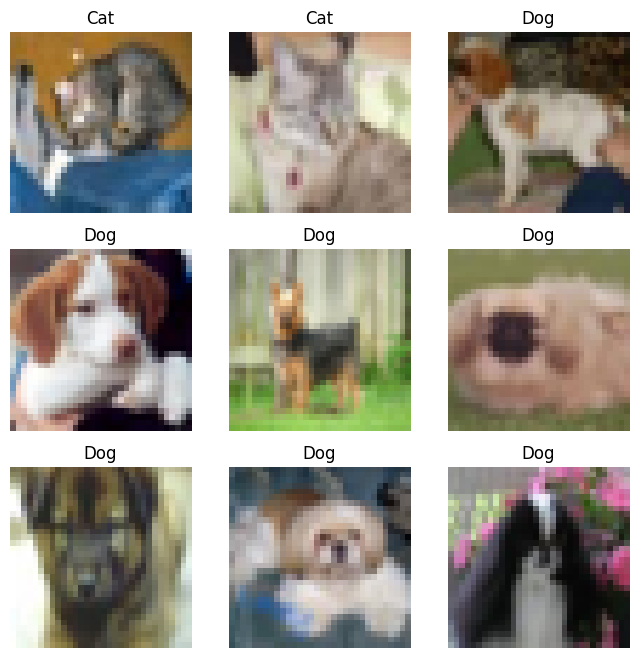

In [11]:
import numpy as np

# neem 1 batch uit de test dataset
for images, labels in test_ds.take(1):
    predictions = model.predict(images[:9])

    plt.figure(figsize=(8,8))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])

        pred_label = "Dog" if predictions[i] > 0.5 else "Cat"
        true_label = "Dog" if labels[i] else "Cat"

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")

    plt.show()

## Opdracht

Probeer het model te verbeteren.

Experimenteer met:

1. Meer **epochs** (bijvoorbeeld 10)
2. Meer **neuronen in de Dense layer**
3. Een extra **Conv2D layer**

Wat gebeurt er met de accuracy?